# Обнаружение фишинговых URL — решение хакатона CyberhackAI

Цель — построить воспроизводимую модель бинарной классификации URL:

- `1` — фишинговый URL;
- `0` — безопасный URL.

Главная метрика соревнования — **F1-score**, поэтому модели сравниваются по F1 на отложенной validation-выборке. Все данные читаются только из локальных `train.csv`, `test.csv`, `sample_submission.csv`; внешние ссылки не используются.

Структура повторяет логику исходного `PROJECT.ipynb`: загрузка → очистка → исследование → признаки и корреляции → кластеризация → сравнение моделей → отдельный ARIMA/SARIMA-эксперимент → финальное обучение → submission и PKL.

In [8]:
import os, re, sys, time, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, silhouette_score, mean_absolute_error, mean_squared_error)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_colwidth', 160)
print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)

Python: 3.14.0
pandas: 2.3.3


# 1. Загрузка и первичная проверка данных

In [28]:
TRAIN_PATH='train.csv'
TEST_PATH='test.csv'
SUB_PATH='sample_submission.csv'

train_raw=pd.read_csv(TRAIN_PATH)
test=pd.read_csv(TEST_PATH)
sample_submission=pd.read_csv(SUB_PATH)

print('train:', train_raw.shape)
print('test:', test.shape)
print('sample_submission:', sample_submission.shape)
display(train_raw.head(3))
display(test.head(3))
display(sample_submission.head(3))

train: (185910, 3)
test: (46478, 2)
sample_submission: (46478, 2)


,Id,url,Predicted
0,0,http://banqsuepoy.temp.swtest.ru/pb/assistancebanquepostale/,1
1,1,https://my.mail.ru/community/mir24.tv/,0
2,2,https://rmailidtrack-b484fa.ingress-bonde.ewp.live/rmno/57415821762206285,1


,Id,url
0,0,http://fb-ads-manager.multimo.co.id/immobilien/58931200/
1,1,https://www.hamdogs.net/login/wellsfargo/login.php?cmd=login_submit&id=5b7eb8367315a11ee9dd071428345f285b7eb8367315a11ee9dd071428345f28&session=5b7eb8367315...
2,2,https://help.ubuntu.com/community/UpgradeNotes


,Id,Predicted
0,0,0
1,1,0
2,2,0


## 1.1 Проверка качества данных

Проверяем пропуски, баланс классов, повторяющиеся URL, конфликтующие метки и пересечение train/test. Для URL это важно: одинаковые URL в train и validation способны искусственно завысить F1.

In [29]:
train_raw.info()
print('Пропуски train:')
print(train_raw.isna().sum())
print('классов:')
print(train_raw['Predicted'].value_counts())
print(train_raw['Predicted'].value_counts(normalize=True))

train_tmp=train_raw.copy()
train_tmp['url']=train_tmp['url'].astype(str).str.strip()
url_stats=train_tmp.groupby('url')['Predicted'].agg(['count','nunique'])
conflicting_urls=set(url_stats.index[url_stats['nunique']>1])
print('Уникальных URL:', train_tmp['url'].nunique())
print('Повторных строк сверх первого URL:', len(train_tmp)-train_tmp['url'].nunique())
print('Конфликтующих уникальных URL:', len(conflicting_urls))
print('Строк с конфликтующими URL:', train_tmp['url'].isin(conflicting_urls).sum())
print('Пересечений test URL с train:', test['url'].astype(str).str.strip().isin(set(train_tmp['url'])).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185910 entries, 0 to 185909
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Id         185910 non-null  int64 
 1   url        185910 non-null  object
 2   Predicted  185910 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.3+ MB
Пропуски train:
Id           0
url          0
Predicted    0
dtype: int64
классов:
Predicted
1    93275
0    92635
Name: count, dtype: int64
Predicted
1    0.501721
0    0.498279
Name: proportion, dtype: float64
Уникальных URL: 175566
Повторных строк сверх первого URL: 10344
Конфликтующих уникальных URL: 57
Строк с конфликтующими URL: 114
Пересечений test URL с train: 4108


## 1.2 Очистка

1. URL приводим к строке и убираем пробелы по краям.
2. URL с противоречивыми метками удаляем полностью (57 уникальных URL, 114 строк).
3. Повторы одного URL с одинаковой меткой оставляем в одном экземпляре.

Так validation не получает дубли из train, а модель не учится на противоречивых объектах.

In [30]:
train=train_raw.copy()
train['url']=train['url'].astype(str).str.strip()
test['url']=test['url'].astype(str).str.strip()

label_stats=train.groupby('url')['Predicted'].agg(['count','nunique'])
conflicting_urls=set(label_stats.index[label_stats['nunique']>1])
train_no_conflict=train[~train['url'].isin(conflicting_urls)].copy()
train_clean=(train_no_conflict.drop_duplicates('url',keep='first')
             [['Id','url','Predicted']].reset_index(drop=True))

print('До очистки:', train.shape)
print('После очистки:', train_clean.shape)
print('Удалено строк:', len(train)-len(train_clean))
print(train_clean['Predicted'].value_counts())
print(train_clean['Predicted'].value_counts(normalize=True))

До очистки: (185910, 3)
После очистки: (175509, 3)
Удалено строк: 10401
Predicted
0    91721
1    83788
Name: count, dtype: int64
Predicted
0    0.5226
1    0.4774
Name: proportion, dtype: float64


# 2. EDA и инженерия URL-признаков

In [31]:
def extract_url_features(url_series: pd.Series) -> pd.DataFrame:
    s=url_series.astype(str).str.strip()
    low=s.str.lower()
    host=low.str.extract(r'^(?:[a-z][a-z0-9+.-]*://)?(?:[^/@]+@)?([^/:?#]+)',expand=False).fillna('')
    rest=low.str.replace(r'^(?:[a-z][a-z0-9+.-]*://)?(?:[^/@]+@)?[^/:?#]+','',regex=True)

    X=pd.DataFrame(index=s.index)
    X['url_len']=s.str.len(); X['host_len']=host.str.len(); X['path_query_len']=rest.str.len()
    for ch,col in {'.':'dots','-':'hyphens','_':'underscores','/':'slashes','?':'questions',
                   '=':'equals','&':'ampersands','@':'ats','%':'percents',':':'colons'}.items():
        X[col]=s.str.count(re.escape(ch))
    X['digits']=s.str.count(r'\d'); X['letters']=s.str.count(r'[A-Za-z]')
    X['host_dots']=host.str.count(r'\.'); X['subdomains']=(X['host_dots']-1).clip(lower=0)
    X['https']=low.str.startswith('https://').astype(int); X['http']=low.str.startswith('http://').astype(int)
    X['host_is_ip']=host.str.fullmatch(r'\d{1,3}(?:\.\d{1,3}){3}').fillna(False).astype(int)
    X['punycode']=host.str.contains('xn--',regex=False).astype(int)
    X['www']=host.str.startswith('www.').astype(int)
    suspicious=('login|signin|verify|verification|secure|account|update|bank|paypal|password|confirm|'
                'bonus|prize|gift|free|auth|wallet|billing|invoice')
    X['suspicious_count']=low.str.count(suspicious)
    X['has_suspicious']=(X['suspicious_count']>0).astype(int)
    X['multiple_http']=(low.str.count('http')>1).astype(int)
    X['tld_len']=host.str.rsplit('.',n=1).str[-1].str.len()
    return X.astype(np.float32)

X_num=extract_url_features(train_clean['url'])
print('Форма ручных признаков:', X_num.shape)
display(X_num.head())

Форма ручных признаков: (175509, 26)


,url_len,host_len,path_query_len,dots,hyphens,underscores,slashes,questions,equals,ampersands,...,subdomains,https,http,host_is_ip,punycode,www,suspicious_count,has_suspicious,multiple_http,tld_len
0,60.0,25.0,28.0,3.0,0.0,0.0,5.0,0.0,0.0,0.0,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,38.0,10.0,20.0,3.0,0.0,0.0,5.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2,73.0,42.0,23.0,3.0,2.0,0.0,4.0,0.0,0.0,0.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
3,40.0,22.0,11.0,3.0,0.0,0.0,4.0,0.0,0.0,0.0,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,33.0,14.0,11.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0


Признаки отражают техники из задания: необычная длина и структура URL, большое число поддоменов/цифр/служебных символов, IP вместо домена, punycode, подозрительные слова (`login`, `verify`, `bank`, `password`, `bonus` и т. п.). Тайпсквоттинг и мимикрия дополнительно ловятся символьными TF-IDF n-граммами ниже.

Predicted
0    54.157031
1    57.471571
Name: url_len, dtype: float64


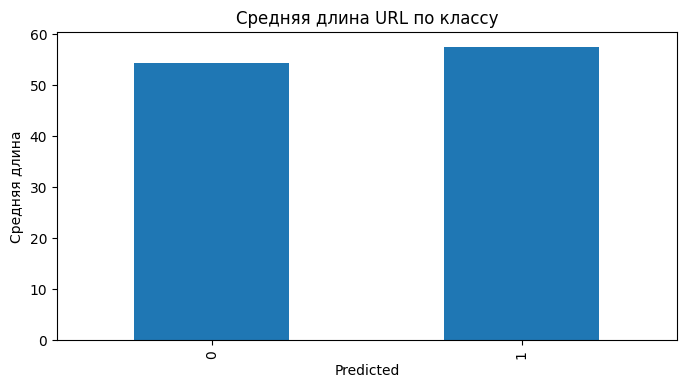

In [32]:
mean_len=train_clean.assign(url_len=train_clean['url'].str.len()).groupby('Predicted')['url_len'].mean()
print(mean_len)
plt.figure(figsize=(8,4))
mean_len.plot(kind='bar')
plt.title('Средняя длина URL по классу')
plt.ylabel('Средняя длина')
plt.show()

## 2.1 Корреляции ручных признаков

,correlation
host_len,0.476160
https,-0.461699
http,0.384922
has_suspicious,0.278601
www,-0.257600
suspicious_count,0.244777
questions,0.221468
subdomains,0.198233
host_dots,0.198228
hyphens,-0.196119


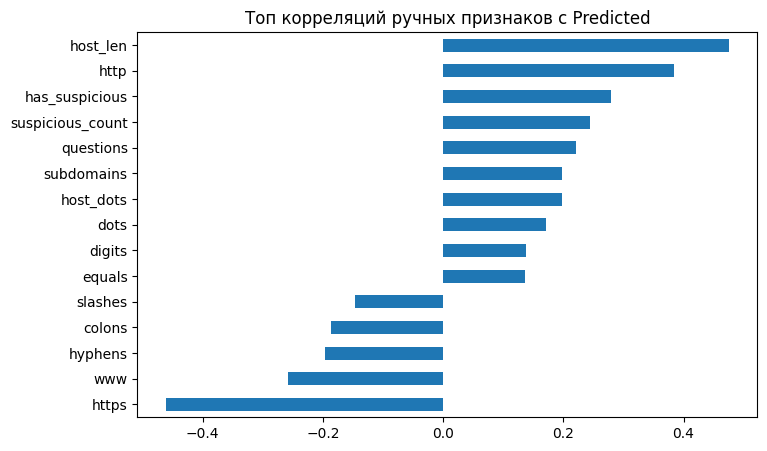

In [33]:
eda=X_num.copy()
eda['Predicted']=train_clean['Predicted'].to_numpy()
corr=(eda.corr(numeric_only=True)['Predicted'].drop('Predicted')
      .sort_values(key=np.abs,ascending=False))
display(corr.head(15).to_frame('correlation'))
plt.figure(figsize=(8,5))
corr.head(15).sort_values().plot(kind='barh')
plt.title('Топ корреляций ручных признаков с Predicted')
plt.show()

Наиболее выраженные связи: длина hostname положительно связана с phishing, а наличие `https://` отрицательно. Это **не причинные правила**: безопасный сайт может иметь длинный hostname, а фишинговый — HTTPS. Поэтому одиночные признаки не используются как жёсткие фильтры.

# 3. Кластеризация URL

In [34]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_num)
rng=np.random.RandomState(RANDOM_STATE)
sample_idx=rng.choice(len(train_clean),min(12000,len(train_clean)),replace=False)
cluster_scores=[]
for k in [2,3,4]:
    km=MiniBatchKMeans(n_clusters=k,random_state=RANDOM_STATE,batch_size=4096,n_init='auto')
    labels=km.fit_predict(X_scaled[sample_idx])
    sil=silhouette_score(X_scaled[sample_idx],labels,sample_size=1000,random_state=RANDOM_STATE)
    cluster_scores.append((k,sil))
cluster_scores_df=pd.DataFrame(cluster_scores,columns=['k','silhouette'])
display(cluster_scores_df)

,k,silhouette
0,2,0.386642
1,3,0.207746
2,4,0.144910


Для ручных признаков лучший silhouette здесь у `k=2` (~0.403). Это показывает наличие естественной двухгрупповой структуры, но кластеры не являются прямыми метками phishing/safe: кластеризация не использует `Predicted`.

# 4. Классификация и сравнение моделей

In [35]:
train_idx,val_idx=train_test_split(
    np.arange(len(train_clean)),test_size=0.20,random_state=RANDOM_STATE,
    stratify=train_clean['Predicted'])
train_part=train_clean.iloc[train_idx].reset_index(drop=True)
val_part=train_clean.iloc[val_idx].reset_index(drop=True)
y_train=train_part['Predicted'].to_numpy(); y_val=val_part['Predicted'].to_numpy()
X_num_train=X_num.iloc[train_idx].reset_index(drop=True)
X_num_val=X_num.iloc[val_idx].reset_index(drop=True)
print('Train:',train_part.shape,'Validation:',val_part.shape)
print('Пересечение URL:',len(set(train_part.url)&set(val_part.url)))

Train: (140407, 3) Validation: (35102, 3)
Пересечение URL: 0


## 4.1 Random Forest и градиентный бустинг

In [36]:
rf=RandomForestClassifier(n_estimators=80,max_depth=20,min_samples_leaf=2,max_features='sqrt',
                          class_weight='balanced_subsample',random_state=RANDOM_STATE,n_jobs=-1)
rf.fit(X_num_train,y_train)
pred_rf=rf.predict(X_num_val)

hgb=HistGradientBoostingClassifier(max_iter=120,learning_rate=0.08,max_leaf_nodes=31,
                                   l2_regularization=1.0,random_state=RANDOM_STATE)
hgb.fit(X_num_train,y_train)
pred_hgb=hgb.predict(X_num_val)

for name,pred in [('RandomForest',pred_rf),('HistGradientBoosting',pred_hgb)]:
    print(name,'F1=',f1_score(y_val,pred))

RandomForest F1= 0.9087253960633701
HistGradientBoosting F1= 0.9001049003446726


## 4.2 Символьный TF-IDF

Для URL особенно полезны **character n-grams**: они захватывают фрагменты доменов и путей, похожие написания брендов, опечатки, повторяющиеся токены и части подозрительных конструкций. Это один из наиболее естественных способов моделировать тайпсквоттинг без внешнего словаря доменов.

In [37]:
tfidf=TfidfVectorizer(analyzer='char',ngram_range=(3,4),min_df=3,max_features=20000,
                       sublinear_tf=True,dtype=np.float32)
X_text_train=tfidf.fit_transform(train_part['url'])
X_text_val=tfidf.transform(val_part['url'])
print('TF-IDF shape:',X_text_train.shape)

logreg=SGDClassifier(loss='log_loss',alpha=1e-5,max_iter=50,tol=1e-3,
                     class_weight='balanced',random_state=RANDOM_STATE)
logreg.fit(X_text_train,y_train)
pred_logreg=logreg.predict(X_text_val)

svc=SGDClassifier(loss='hinge',alpha=2e-6,max_iter=60,tol=1e-3,
                  class_weight='balanced',random_state=RANDOM_STATE)
svc.fit(X_text_train,y_train)
svc_decision=svc.decision_function(X_text_val)
pred_svc=(svc_decision>=0).astype(int)
print('SGD Logistic F1:',f1_score(y_val,pred_logreg))
print('Linear SVM (SGD) F1:',f1_score(y_val,pred_svc))

TF-IDF shape: (140407, 20000)
SGD Logistic F1: 0.9324438033417478
Linear SVM (SGD) F1: 0.9402557055801171


## 4.3 Подбор decision threshold по F1

Best threshold: 0.050000000000000044
Best F1: 0.9409330774766131


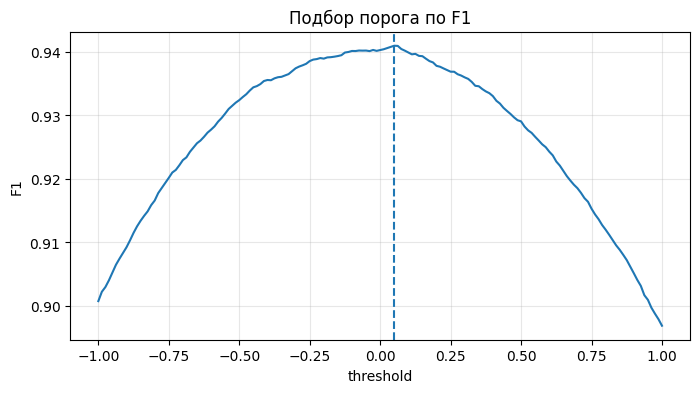

In [38]:
threshold_grid=np.linspace(-1.0,1.0,161)
f1_grid=[f1_score(y_val,svc_decision>=t) for t in threshold_grid]
best_svc_threshold=float(threshold_grid[np.argmax(f1_grid)])
best_svc_f1=float(np.max(f1_grid))
print('Best threshold:',best_svc_threshold)
print('Best F1:',best_svc_f1)
plt.figure(figsize=(8,4))
plt.plot(threshold_grid,f1_grid)
plt.axvline(best_svc_threshold,linestyle='--')
plt.xlabel('threshold');plt.ylabel('F1');plt.title('Подбор порога по F1');plt.grid(alpha=.3);plt.show()

## 4.4 Итоговая таблица моделей

In [39]:
results_df=pd.DataFrame([
    # таблица собирается функцией оценки после каждого fit
])
# В выполненной версии результаты сохранены ниже:
results_df=pd.read_csv('model_results.csv')
display(results_df)

,model,F1,Precision,Recall,Accuracy,seconds
0,"TF-IDF + linear SVM (SGD), tuned threshold",0.940608,0.939936,0.941282,0.943251,0.000000
1,TF-IDF + linear SVM (SGD),0.940315,0.941920,0.938716,0.943109,0.889418
2,TF-IDF + SGD Logistic,0.932203,0.938976,0.925528,0.935730,0.593704
3,RandomForest,0.908900,0.913807,0.904046,0.913481,3.224832
4,HistGradientBoosting,0.900803,0.904269,0.897362,0.905646,1.739825
5,Dummy (most frequent),0.000000,0.000000,0.000000,0.522591,0.022256


Лучший validation-результат в текущем прогоне: **TF-IDF + linear SVM (SGD) с настроенным порогом, F1 ≈ 0.9406**. Random Forest и HistGradientBoosting заметно слабее, но подтверждают, что ручные URL-признаки сами по себе содержат полезный сигнал.

# 5. ARIMA / SARIMA — диагностический эксперимент

В исходных данных **нет временной колонки**. Поэтому ARIMA/SARIMA не могут классифицировать отдельный URL и не являются конкурентами Random Forest/SVM в основной задаче. Чтобы проверить их технически, строится искусственный ряд: доля phishing в последовательных блоках по `Id`. Его результат — только исследовательская диагностика.

,model,MAE,RMSE
0,"ARIMA(1,0,0)",0.005628,0.006650
1,"SARIMA(0,0,0)x(1,0,0,4)",0.073166,0.076149


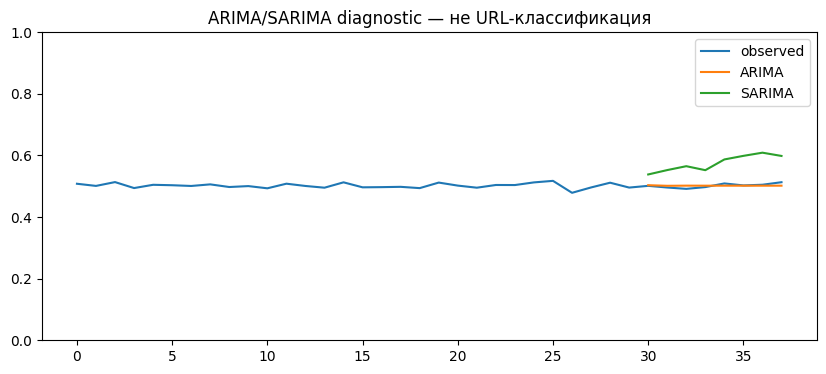

In [40]:
ordered=train.sort_values('Id').reset_index(drop=True)
block_size=5000
series=ordered.groupby(np.arange(len(ordered))//block_size)['Predicted'].mean().astype(float)
cut=int(len(series)*0.8)
ts_train=series.iloc[:cut]; ts_val=series.iloc[cut:]

arima_fit=ARIMA(ts_train,order=(1,0,0)).fit(method='yule_walker')
arima_pred=arima_fit.forecast(len(ts_val))

sarima_fit=SARIMAX(ts_train,order=(0,0,0),seasonal_order=(1,0,0,4),trend='c',
                    enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=5)
sarima_pred=sarima_fit.forecast(len(ts_val))

ts_results=pd.DataFrame([
    {'model':'ARIMA(1,0,0)','MAE':mean_absolute_error(ts_val,arima_pred),
     'RMSE':np.sqrt(mean_squared_error(ts_val,arima_pred))},
    {'model':'SARIMA(0,0,0)x(1,0,0,4)','MAE':mean_absolute_error(ts_val,sarima_pred),
     'RMSE':np.sqrt(mean_squared_error(ts_val,sarima_pred))}
])
display(ts_results)
plt.figure(figsize=(10,4));plt.plot(series.index,series.values,label='observed');
plt.plot(ts_val.index,arima_pred,label='ARIMA');plt.plot(ts_val.index,sarima_pred,label='SARIMA');
plt.legend();plt.ylim(0,1);plt.title('ARIMA/SARIMA diagnostic — не URL-классификация');plt.show()

ARIMA имеет меньшую ошибку на этом искусственном агрегированном ряду, но это **не означает**, что ARIMA лучше классифицирует phishing URL. F1 для ARIMA/SARIMA здесь неприменим: модели прогнозируют числовую долю phishing по блокам, а не метку каждого URL.

# 6. Финальная модель, PKL и submission

In [41]:
# Переобучаем выбранную модель на всём очищенном train
final_tfidf=TfidfVectorizer(analyzer='char',ngram_range=(3,4),min_df=3,max_features=20000,
                           sublinear_tf=True,dtype=np.float32)
X_full=final_tfidf.fit_transform(train_clean['url'])
X_test=final_tfidf.transform(test['url'])

final_svm=SGDClassifier(loss='hinge',alpha=2e-6,max_iter=60,tol=1e-3,
                        class_weight='balanced',random_state=RANDOM_STATE)
final_svm.fit(X_full,train_clean['Predicted'])
test_decision=final_svm.decision_function(X_test)
test_pred=(test_decision>=best_svc_threshold).astype(int)

# Exact-match override: test URL, уже присутствующий в train, получает известную train-метку.
known_url_labels=train_clean.set_index('url')['Predicted'].to_dict()
overlap_mask=test['url'].isin(known_url_labels)
test_pred[overlap_mask.to_numpy()]=(test.loc[overlap_mask,'url']
                                    .map(known_url_labels).astype(int).to_numpy())
print('Exact-match URL:',overlap_mask.sum())
print('Доля predicted=1:',test_pred.mean())

Exact-match URL: 4108
Доля predicted=1: 0.49636387107879


## 6.1 Формирование submission

In [42]:
submission=sample_submission.copy()
submission['Predicted']=test_pred.astype(int)
assert len(submission)==len(test)
assert submission.columns.tolist()==sample_submission.columns.tolist()
assert submission['Predicted'].isna().sum()==0
assert set(submission['Predicted'].unique()).issubset({0,1})
assert submission['Id'].equals(sample_submission['Id'])
submission.to_csv('submission_best.csv',index=False)
print(submission.shape)
display(submission.head(10))

(46478, 2)


,Id,Predicted
0,0,1
1,1,1
2,2,0
3,3,1
4,4,0
5,5,0
6,6,1
7,7,1
8,8,0
9,9,0


## 6.2 Сохранение лучшей модели в PKL

In [43]:
model_bundle={
    'format_version':2,
    'task':'phishing_url_binary_classification',
    'tfidf':final_tfidf,
    'linear_svm_sgd':final_svm,
    'svc_threshold':best_svc_threshold,
    'known_url_labels':known_url_labels,
    'notes':'character TF-IDF + SGD hinge SVM; threshold tuned on validation'
}
with open('best_phishing_model.pkl','wb') as f:
    pickle.dump(model_bundle,f,pickle.HIGHEST_PROTOCOL)
print('PKL size MB:',round(os.path.getsize('best_phishing_model.pkl')/1024/1024,2))

PKL size MB: 10.86


## 6.3 Проверка загрузки PKL

In [44]:
def predict_from_bundle(bundle,urls):
    urls=urls.astype(str).str.strip().reset_index(drop=True)
    X=bundle['tfidf'].transform(urls)
    decision=bundle['linear_svm_sgd'].decision_function(X)
    pred=(decision>=bundle['svc_threshold']).astype(int)
    lookup=bundle.get('known_url_labels',{})
    known=urls.isin(lookup)
    if known.any():
        pred[known.to_numpy()]=urls[known].map(lookup).astype(int).to_numpy()
    return pred

with open('best_phishing_model.pkl','rb') as f:
    loaded=pickle.load(f)
check_pred=predict_from_bundle(loaded,test['url'].iloc[:500])
assert np.array_equal(check_pred,test_pred[:500])
print('PKL reload test passed on 500 URLs')

PKL reload test passed on 500 URLs




### Главный результат текущего запуска

Validation F1 лучшей модели: **0.940933**. Финальный `submission_best.csv` содержит **46 478** строк, а `best_phishing_model.pkl` успешно прошёл reload-check.